# EDA - UrbanSound8K

# Импортиране на библиотеки и зареждане на данните

Тази клетка подготвя всичко необходимо и показва как изглежда таблицата

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import warnings

warnings.filterwarnings('ignore') # Скрива досадните предупреждения на librosa

# Пътища до данните
CSV_PATH = "../data/raw/Urban8K/UrbanSound8K.csv"
AUDIO_DIR = "../data/raw/Urban8K/"

# Зареждане на метаданните
df = pd.read_csv(CSV_PATH)

print(f"Общ брой аудио файлове: {len(df)}")
print(f"Брой уникални класове: {df['class'].nunique()}")

unique_classes = sorted(df['class'].unique())
print("\nСписък с всички звуци (класове) в UrbanSound8K:")
for i, class_name in enumerate(unique_classes, 1):
    print(f" {i}. {class_name}")
print("-" * 50 + "\n")


display(df.head())

Общ брой аудио файлове: 8732
Брой уникални класове: 10

Списък с всички звуци (класове) в UrbanSound8K:
 1. air_conditioner
 2. car_horn
 3. children_playing
 4. dog_bark
 5. drilling
 6. engine_idling
 7. gun_shot
 8. jackhammer
 9. siren
 10. street_music
--------------------------------------------------



,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


# Баланс на класовете (Имаме ли достатъчно данни за всеки звук?)

Тази графика е задължителна, за да покажеш дали датасетът е балансиран.

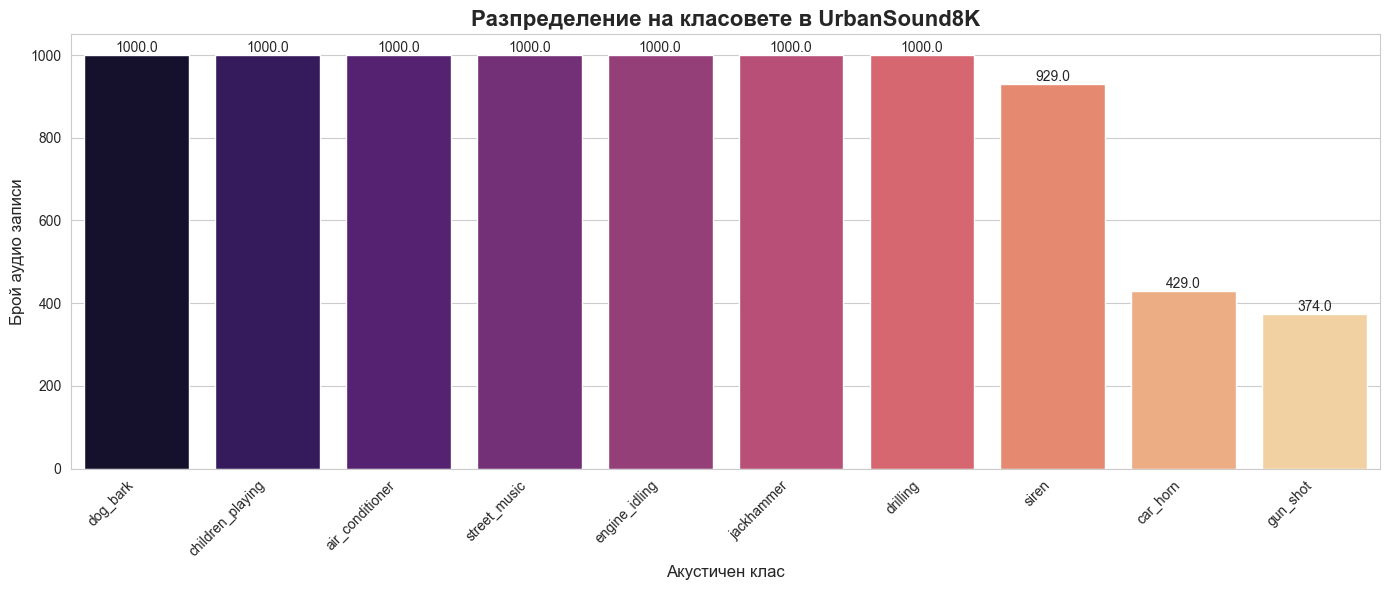

In [8]:
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# Създаваме красива графика (Countplot)
ax = sns.countplot(data=df, x='class', order=df['class'].value_counts().index, palette='magma')

plt.title("Разпределение на класовете в UrbanSound8K", fontsize=16, fontweight='bold')
plt.xlabel("Акустичен клас", fontsize=12)
plt.ylabel("Брой аудио записи", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Добавяме точните числа върху всяко стълбче
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# Проблемът с дължината (Защо ни трябва Padding?)

Тази графика визуално защитава решението ти (в следващия ноутбук) да стандартизираш файловете до 4 секунди. Тъй като изчисляването на дължината на всички 8732 файла отнема време, тук взимаме представителна извадка от 1000 файла.

Изчисляване на дължината на аудио файловете (може да отнеме минута)...


100%|██████████| 1000/1000 [00:04<00:00, 222.39it/s]


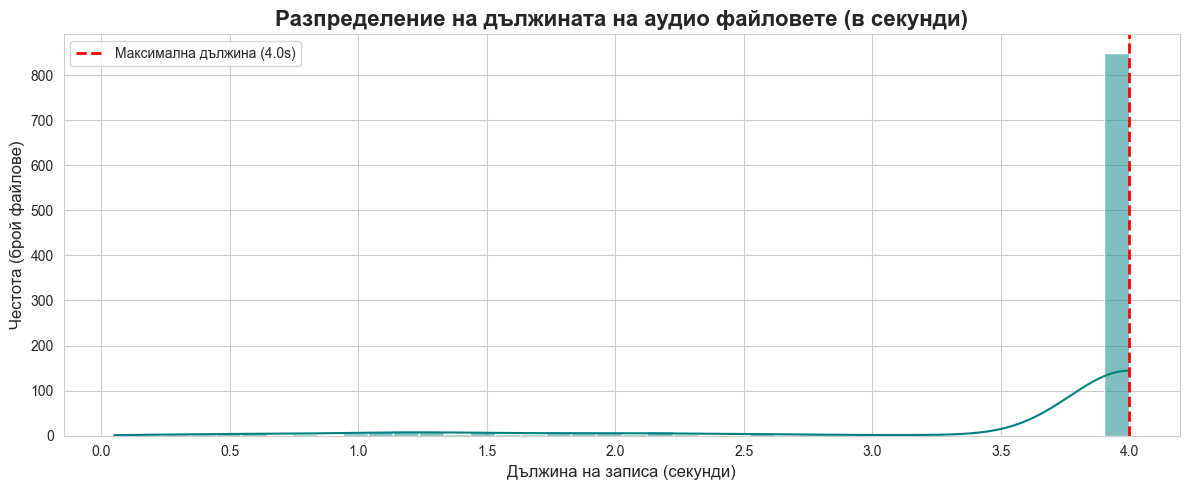

In [9]:
from tqdm import tqdm

# Взимаме случайни 1000 файла за по-бърза обработка
sample_df = df.sample(1000, random_state=42)
durations = []

print("Изчисляване на дължината на аудио файловете (може да отнеме минута)...")
for index, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    filename = row['slice_file_name']
    fold = f"fold{row['fold']}"
    file_path = os.path.join(AUDIO_DIR, fold, filename)
    
    try:
        # Взимаме дължината в секунди
        duration = librosa.get_duration(filename=file_path)
        durations.append(duration)
    except Exception:
        continue

plt.figure(figsize=(12, 5))
sns.histplot(durations, bins=40, kde=True, color='teal')
plt.title("Разпределение на дължината на аудио файловете (в секунди)", fontsize=16, fontweight='bold')
plt.xlabel("Дължина на записа (секунди)", fontsize=12)
plt.ylabel("Честота (брой файлове)", fontsize=12)

# Слагаме червена линия на максимума от 4 секунди
plt.axvline(x=4.0, color='red', linestyle='--', linewidth=2, label='Максимална дължина (4.0s)')
plt.legend()
plt.tight_layout()
plt.show()

# Голямата витрина (Waveform + Mel-Spectrogram)

Това е "черешката на тортата". Ще изберем 5 напълно различни класа (например куче, сирена, бормашина, деца и двигател) и ще покажем тяхната звукова вълна (Waveform) и Мел-спектрограма една до друга.

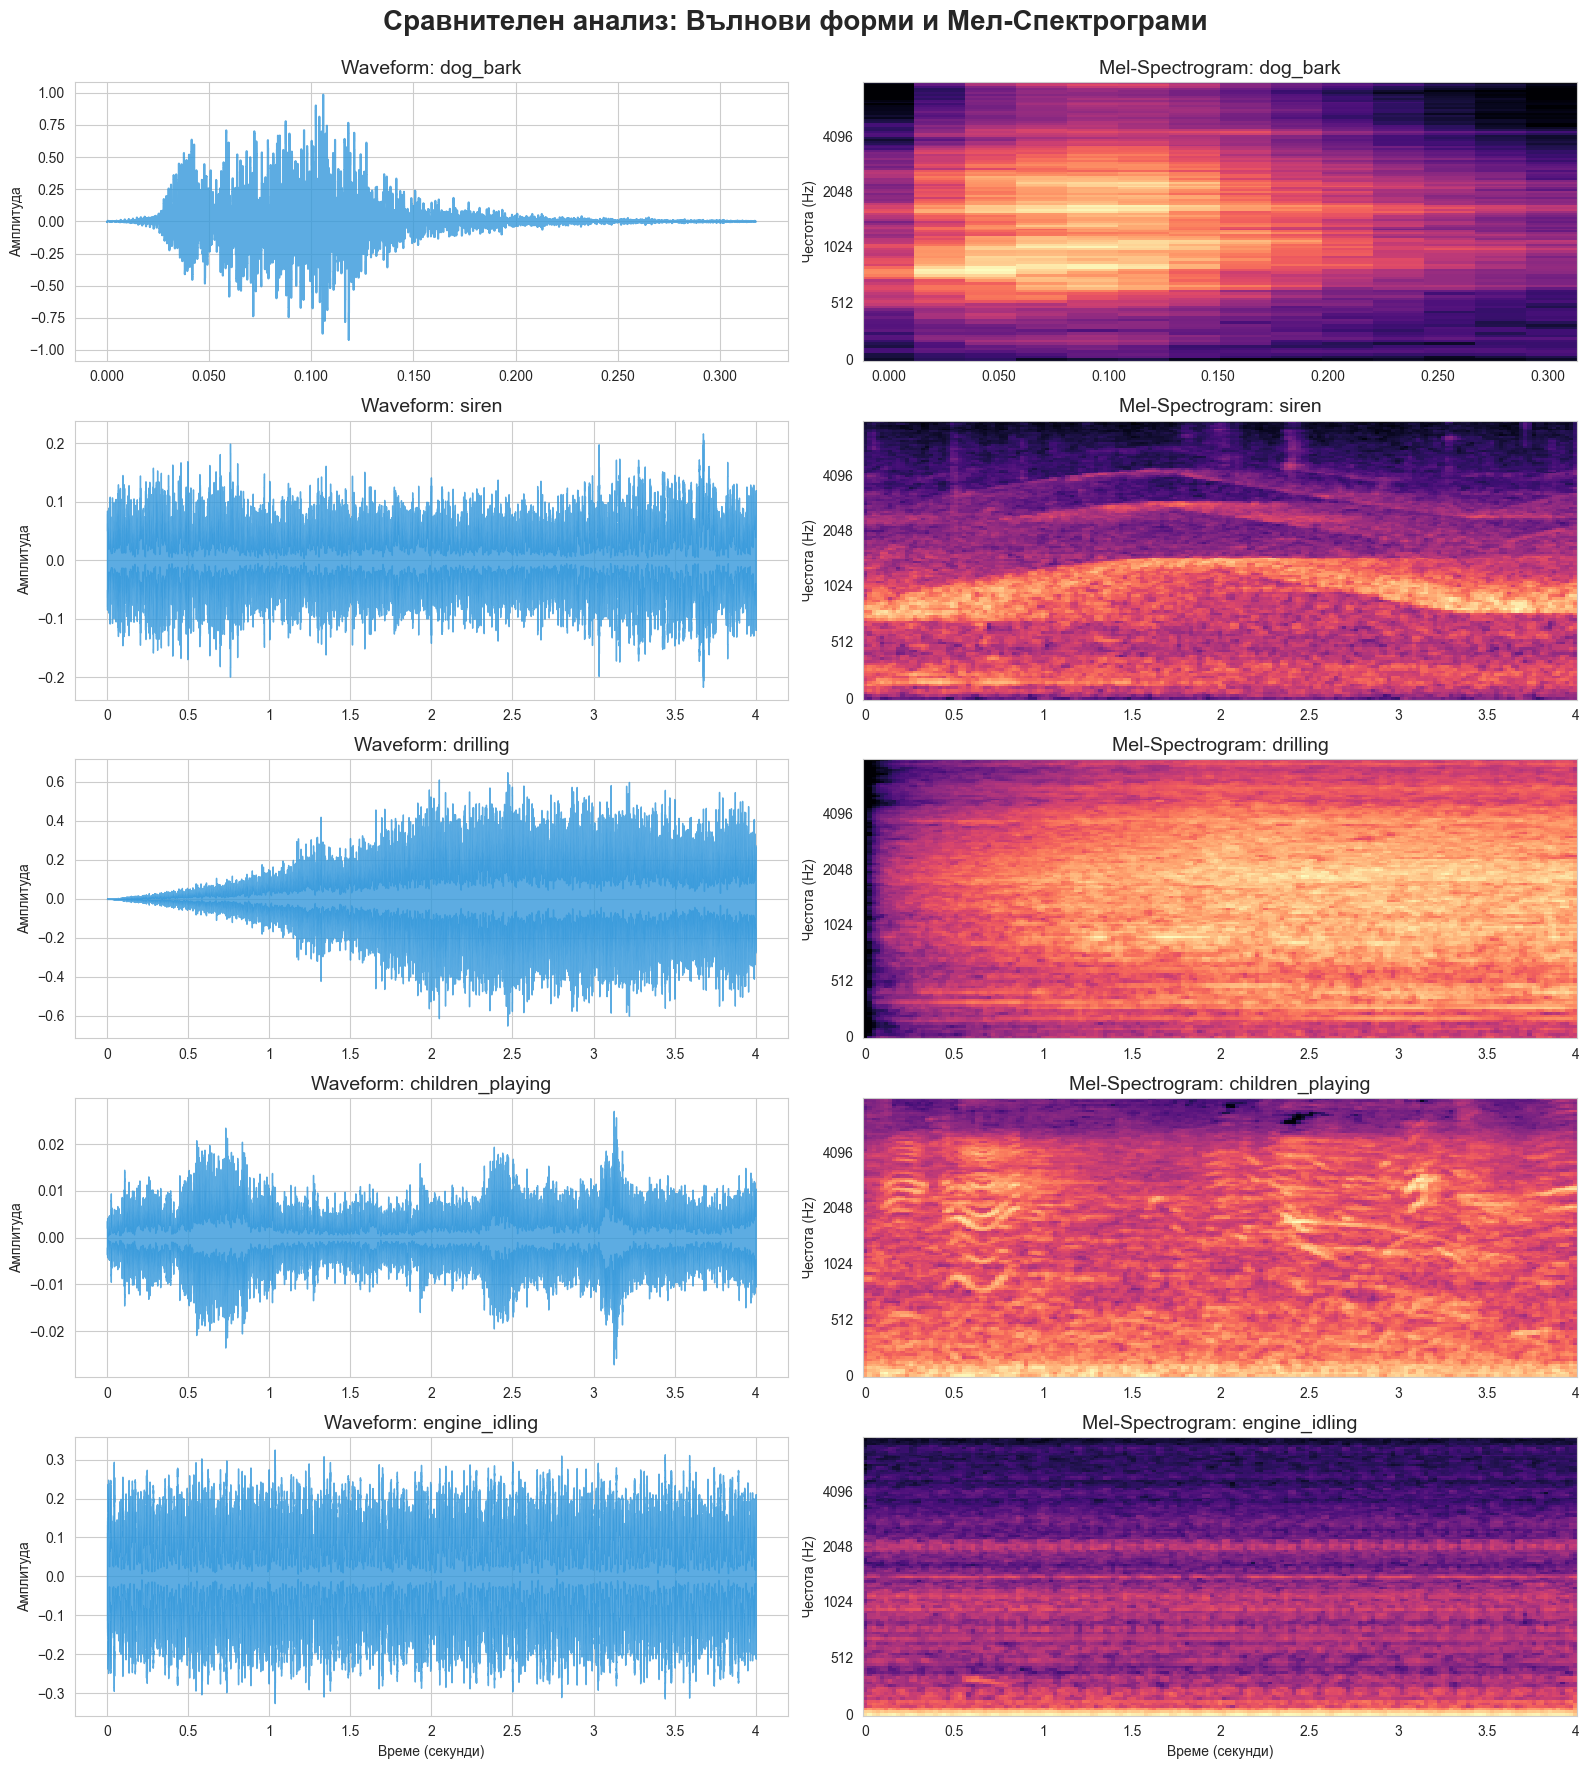

In [10]:
# Избираме 5 интересни и различни класа за сравнение
classes_to_plot = ['dog_bark', 'siren', 'drilling', 'children_playing', 'engine_idling']

# Създаваме голяма мрежа от графики (5 реда, 2 колони)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 18))
fig.suptitle("Сравнителен анализ: Вълнови форми и Мел-Спектрограми", fontsize=20, fontweight='bold', y=0.98)

for i, class_name in enumerate(classes_to_plot):
    # Взимаме първия файл от съответния клас
    sample_row = df[df['class'] == class_name].iloc[0]
    filename = sample_row['slice_file_name']
    fold = f"fold{sample_row['fold']}"
    file_path = os.path.join(AUDIO_DIR, fold, filename)
    
    # Зареждаме аудиото (стандартизираме честотата на 22050 Hz)
    y, sr = librosa.load(file_path, sr=22050)
    
    # --- ЛЯВА КОЛОНА: Звукова вълна (Waveform) ---
    ax_wave = axes[i, 0]
    librosa.display.waveshow(y, sr=sr, ax=ax_wave, color='#3498db', alpha=0.8)
    ax_wave.set_title(f'Waveform: {class_name}', fontsize=14)
    ax_wave.set_ylabel('Амплитуда')
    if i == 4: ax_wave.set_xlabel('Време (секунди)')
    else: ax_wave.set_xlabel('')
    
    # --- ДЯСНА КОЛОНА: Мел-Спектрограма ---
    ax_mel = axes[i, 1]
    # Генерираме спектрограмата
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', 
                                   fmax=8000, cmap='magma', ax=ax_mel)
    ax_mel.set_title(f'Mel-Spectrogram: {class_name}', fontsize=14)
    if i == 4: ax_mel.set_xlabel('Време (секунди)')
    else: ax_mel.set_xlabel('')
    ax_mel.set_ylabel('Честота (Hz)')

# Добавяме легенда (Colorbar) само за спектрограмите

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

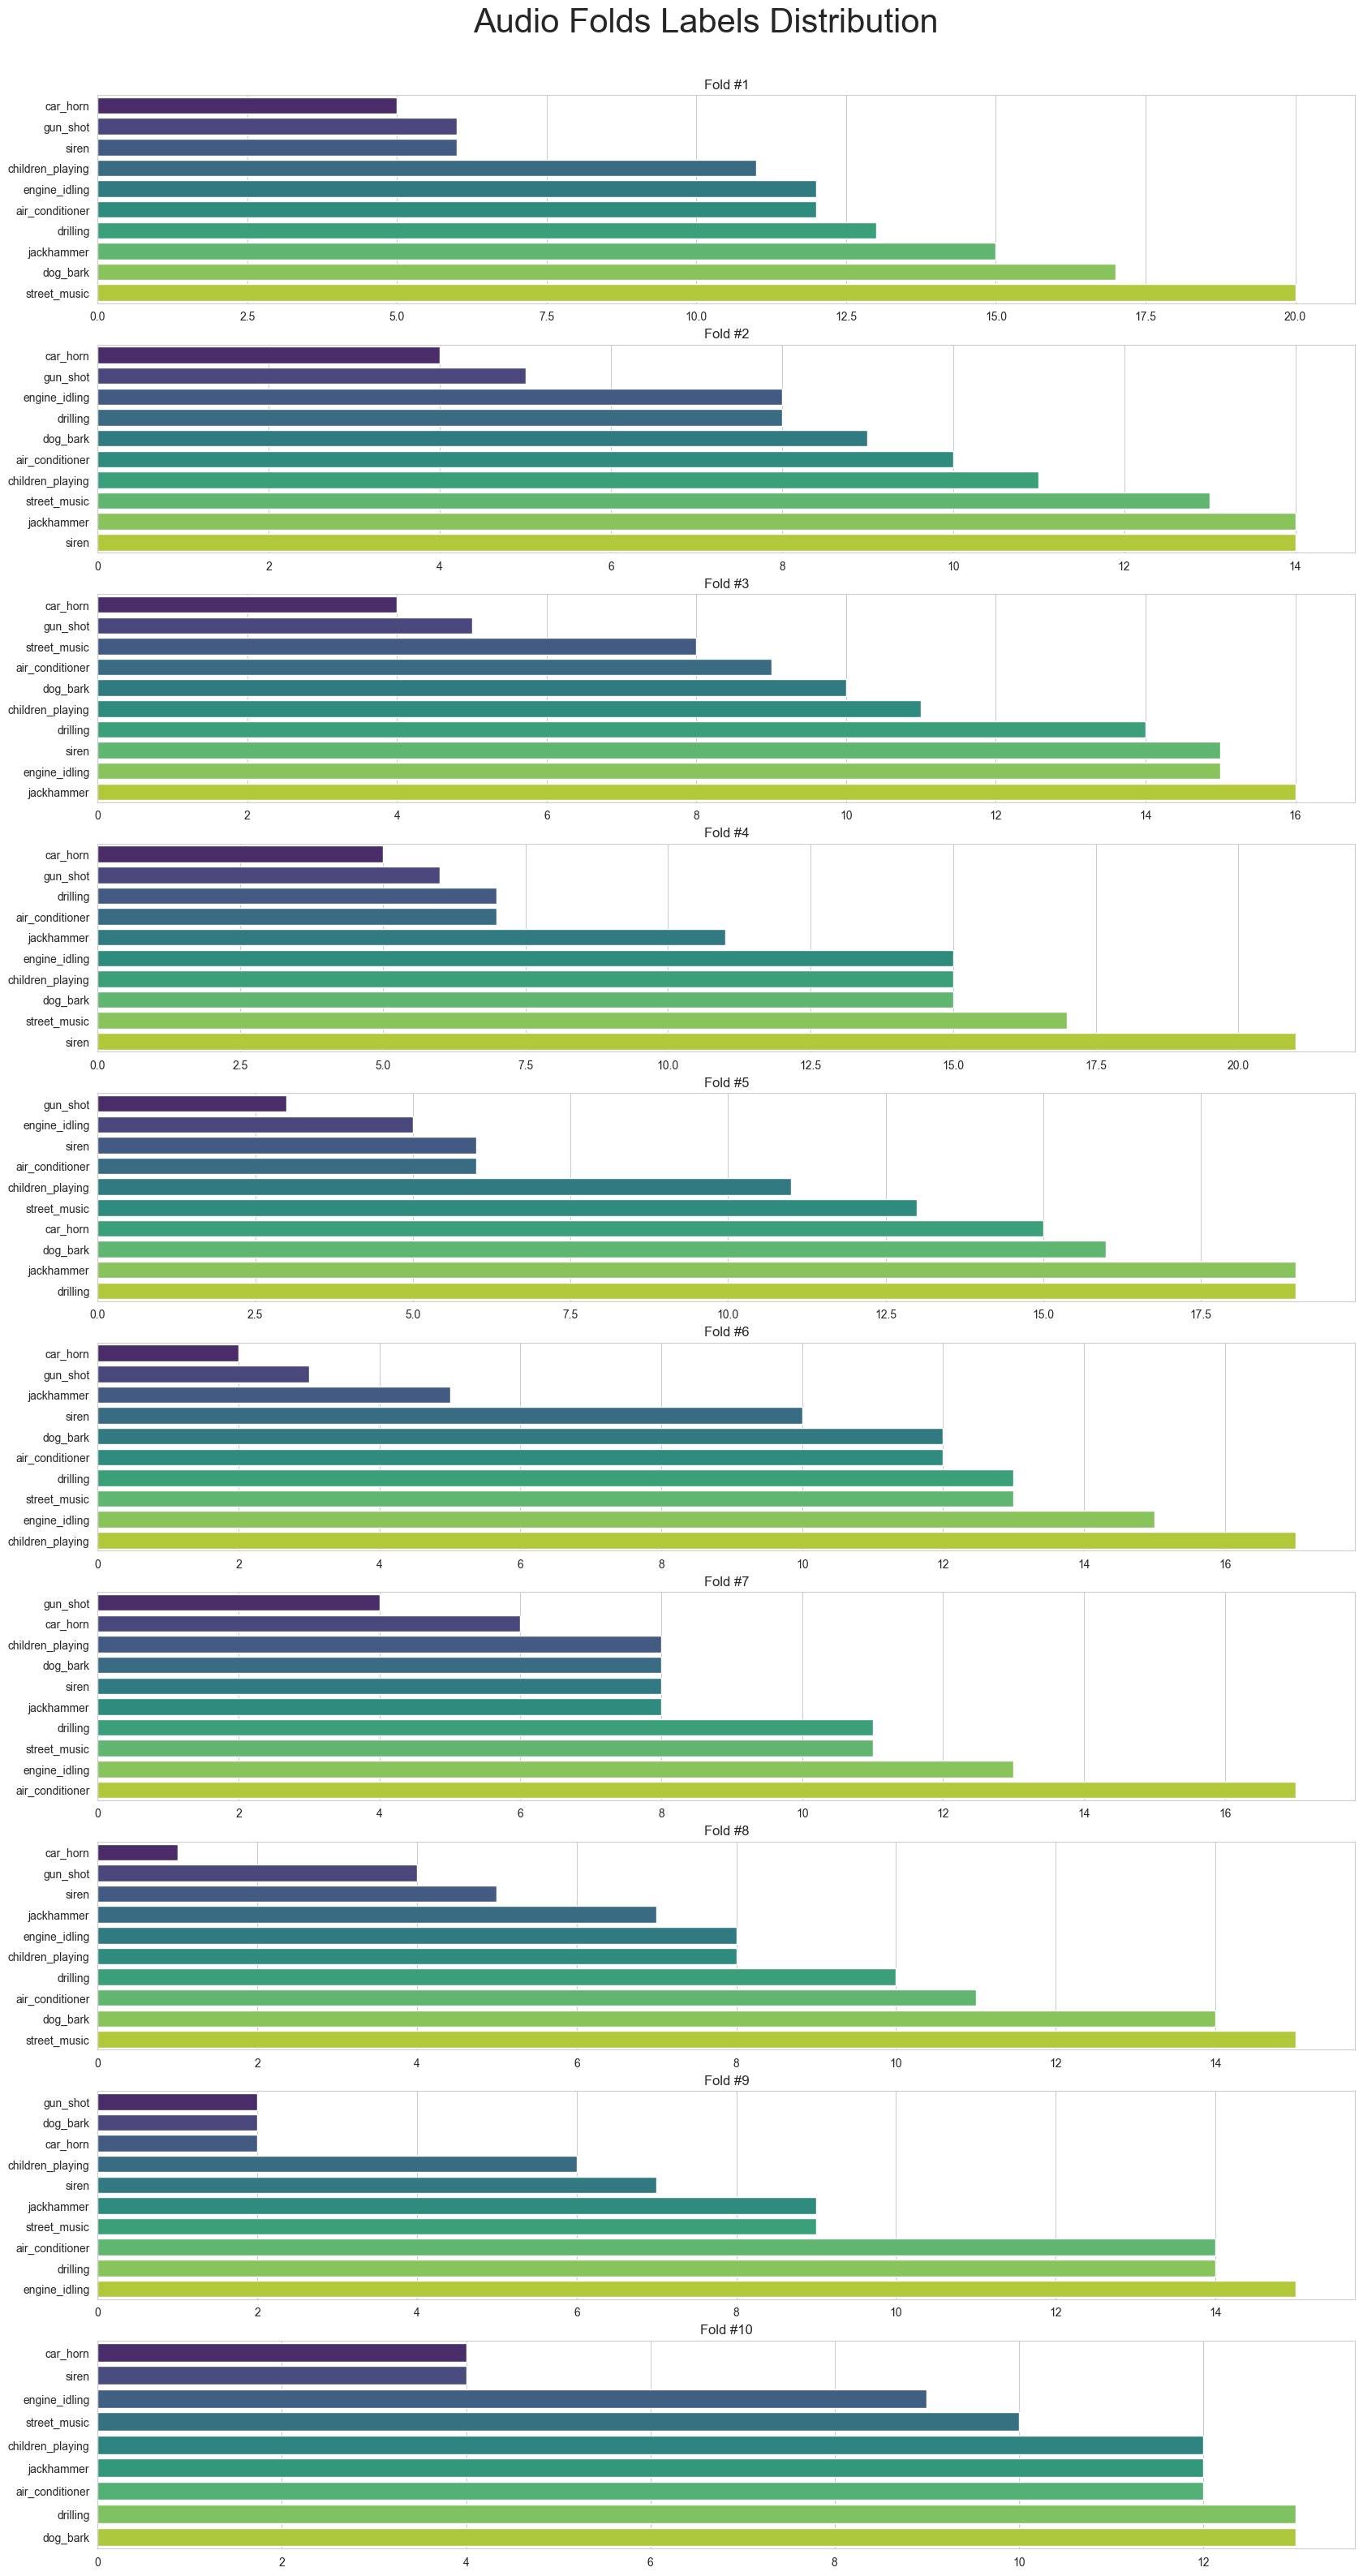

In [12]:
# View Dataset Folds Distribution
fig = plt.figure(figsize=(20, 36))
fig.suptitle('Audio Folds Labels Distribution', fontsize=30)
fig.tight_layout()
fig.subplots_adjust(top=0.95)

folds = sorted(list(df['fold'].drop_duplicates()))
fold_groups = sample_df.groupby(by='fold')

for fold in folds:
    query = fold_groups.get_group(fold)
    class_distribution = query['class'].value_counts().sort_values()
    
    plt.subplot(len(folds), 1, fold)
    plt.title(f'Fold #{fold}')
    
    sns.barplot(
        x=class_distribution.values,
        y=list(class_distribution.keys()),
        palette="viridis"
    );

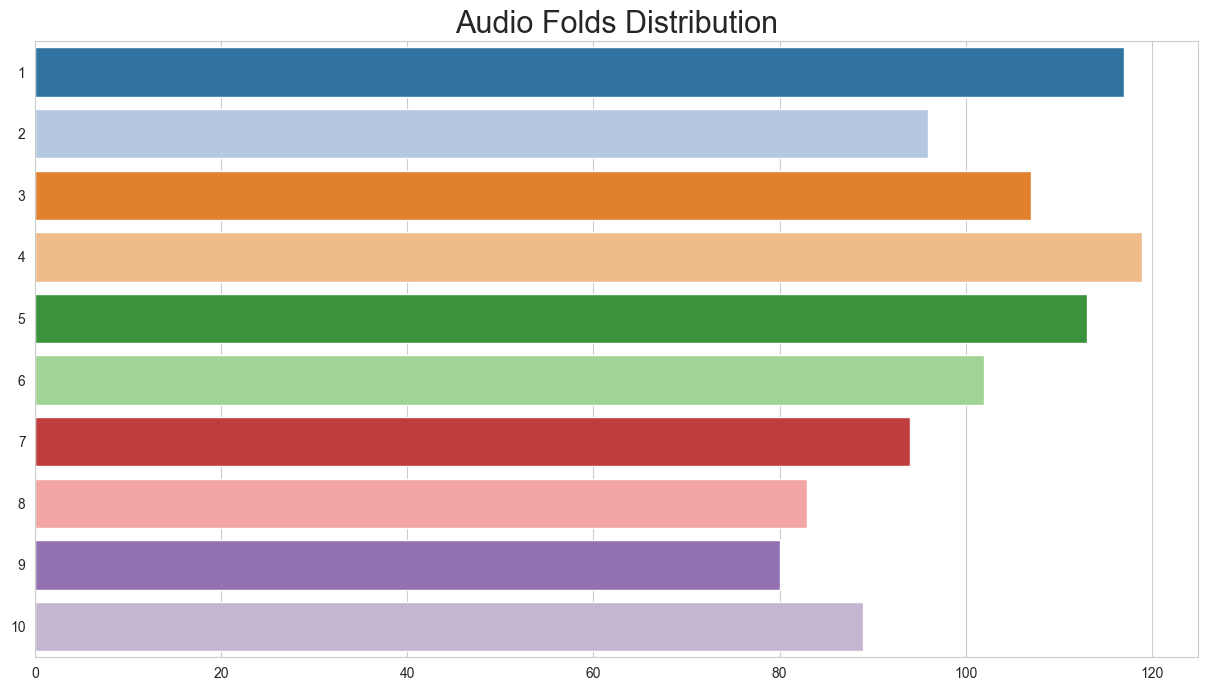

In [13]:
# View Dataset Folds Distribution
plt.figure(figsize=(15, 8))
plt.title('Audio Folds Distribution', fontsize=22)
folds_distribution = sample_df['fold'].value_counts().sort_index()

sns.barplot(x=folds_distribution.values,
            y=list(folds_distribution.keys()),
            orient="h", palette="tab20");

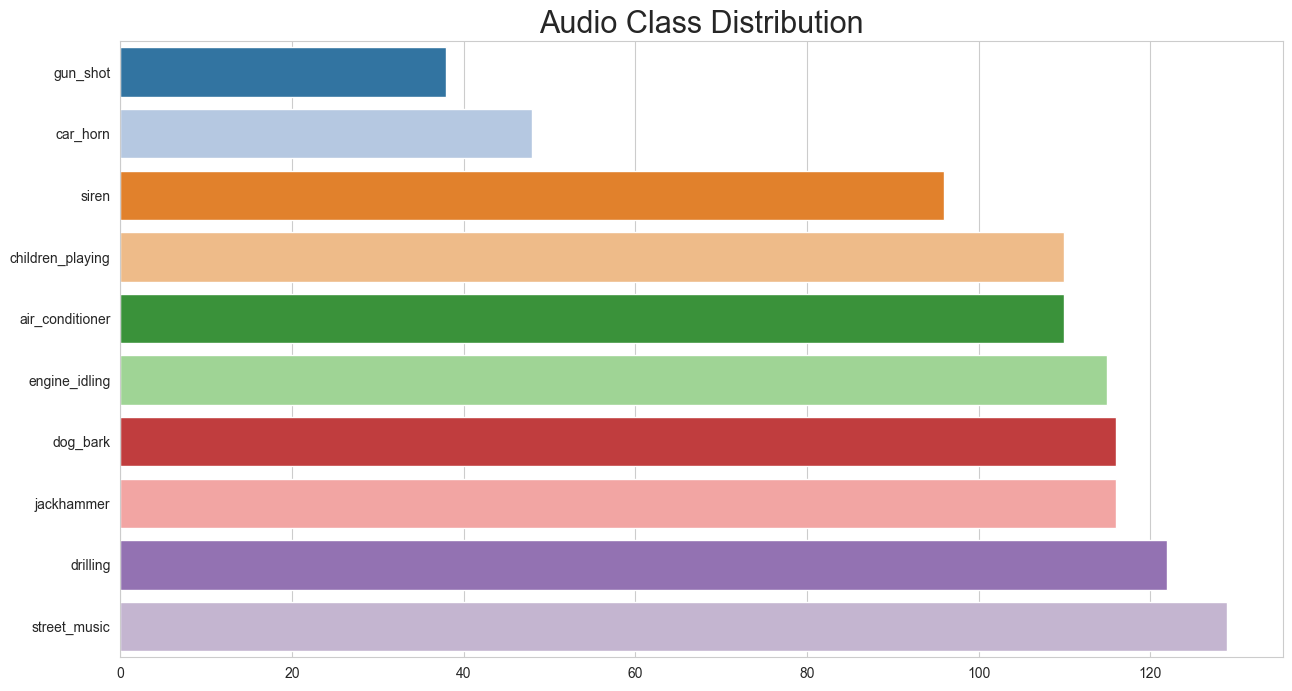

In [14]:
# View Dataset Labels Distribution
plt.figure(figsize=(15, 8))
plt.title('Audio Class Distribution', fontsize=22)
class_distribution = sample_df['class'].value_counts().sort_values()

sns.barplot(x=class_distribution.values,
            y=list(class_distribution.keys()),
            orient="h", palette="tab20");

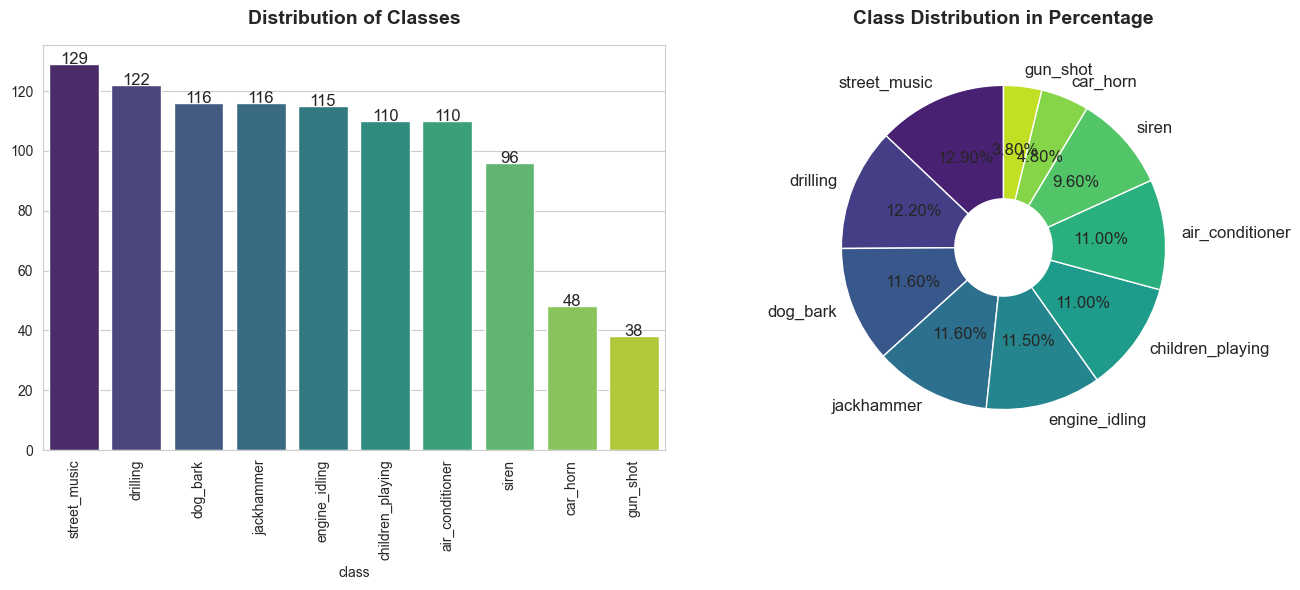

In [15]:
# Lets see the distribution of classes
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
class_counts = sample_df["class"].value_counts()

sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Distribution of Classes", fontweight="bold", size=14, pad=15)

for index, value in enumerate(class_counts.values):
    plt.text(index, value, str(value), ha="center", fontsize=12)

plt.xticks(rotation=90)

plt.subplot(1, 2, 2)
colors = sns.color_palette("viridis", len(class_counts))
plt.pie(class_counts, labels=class_counts.index, autopct="%.2f%%",
        colors=colors, startangle=90, textprops={"fontsize": 12})

center_circle = plt.Circle((0, 0), 0.3, fc="white")
plt.gca().add_artist(center_circle)
plt.title("Class Distribution in Percentage", fontweight="bold", size=14, pad=15)

plt.tight_layout()
plt.show()